<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

population.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"]*1000

In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns = {"Valeur" : "Population"}, inplace = True)

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [10]:
#Consulter le nombre de colonnes
dispo_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jo

In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
liste = ["Aliments pour animaux", "Disponibilité intérieure", "Exportations - Quantité", "Importations - Quantité", "Nourriture", "Pertes", "Production", "Semences", "Traitement", "Variation de stock", "Autres Utilisations"]
dispo_alimentaire[liste] = dispo_alimentaire[liste] * 1000000

In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [16]:
#Consulter le nombre de colonnes
aide_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns = {"Pays bénéficiaire" : "Zone"}, inplace = True)

In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"] * 1000

In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [22]:
#Consulter le nombre de colonnes
sous_nutrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#Conversion de la colonne sous nutrition en numérique
try : 
    sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])    # le script essaye d'executer cette instruction
except :
    pass                                                                  # si une erreur apparaît, il passe directement au bloc suivant et n'affiche rien

In [25]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors = "coerce")

#Puis remplacement des NaN en 0
sous_nutrition["Valeur"] = sous_nutrition["Valeur"].fillna(0)

In [26]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns = {"Valeur" : "Sous_Nutrition"}, inplace = True)

In [27]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["Sous_Nutrition"] = sous_nutrition["Sous_Nutrition"] * 1000000

In [28]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Sous_Nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [29]:
import copy  # importe le module copy de Python pour pouvoir faire des copies des objets contenus dans les datasets originaux et leur appliquer des modifications

sous_nut_corrige = copy.deepcopy(sous_nutrition)  # crée une copie profonde du dataset sous_nutrition afin de pouvoir modifier ses valeurs sans modifier le dataset original
sous_nut_corrige[["annee_deb", "annee_fin"]] = sous_nut_corrige["Année"].str.split("-", expand = True)  # separe les 2 dates en 2 nouvelles valeurs indépendantes, en supprimant le tiret
sous_nut_corrige["annee_deb"] = pd.to_numeric(sous_nut_corrige["annee_deb"], errors = "coerce")  # converti les 2 dates obtenues en valeur numérique
sous_nut_corrige["annee_fin"] = pd.to_numeric(sous_nut_corrige["annee_fin"], errors = "coerce")  #
sous_nut_corrige["Année"] = (sous_nut_corrige["annee_deb"] + sous_nut_corrige["annee_fin"]) / 2   # calcule la moyenne entre les 2 dates obtenues
sous_nut_corrige.drop(columns = ["annee_deb", "annee_fin"], inplace = True)    # supprime les 2 colonnes créées pour le calcul mais non nécessaires

# Convertion de l'intervalle de dates en date moyenne pour l'Année dans le DF sous-nutrition

In [30]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
pop_sous_nut = pd.merge(population, sous_nut_corrige, on = ["Zone", "Année"], how = "inner")
pop_sous_nut_2017 = copy.deepcopy(pop_sous_nut[pop_sous_nut["Année"] == 2017])   # création d'un nouveau DF qui conserve uniquement les lignes correspondant à l'année 2017

In [31]:
#Affichage du dataset
pop_sous_nut_2017

,Zone,Année,Population,Sous_Nutrition
4,Afghanistan,2017,36296113.0,10500000.0
10,Afrique du Sud,2017,57009756.0,3100000.0
16,Albanie,2017,2884169.0,100000.0
22,Algérie,2017,41389189.0,1300000.0
28,Allemagne,2017,82658409.0,0.0
...,...,...,...,...
1192,Venezuela (République bolivarienne du),2017,29402484.0,8000000.0
1198,Viet Nam,2017,94600648.0,6500000.0
1204,Yémen,2017,27834819.0,0.0
1210,Zambie,2017,16853599.0,0.0


In [32]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
nb_sous_nut = sum(pop_sous_nut_2017["Sous_Nutrition"])   
print(f"En 2017, il y a {nb_sous_nut / 1000000} millions de personnes en état de sous nutrition dans le monde.") # la division est utilisée pour que le résultat final soit plus lisible.

En 2017, il y a 535.7 millions de personnes en état de sous nutrition dans le monde.


In [33]:
prop_sous_nut = round((nb_sous_nut / sum(pop_sous_nut_2017["Population"])) *100, 3)  # calcul de la proportion de personnes en sous nutrition par rapport à la population globale mondiale, arrondi à 3 chiffres après la virgule
print(f"En 2017, il y a {prop_sous_nut} % de personnes en état de sous nutrition dans le monde.")

En 2017, il y a 7.101 % de personnes en état de sous nutrition dans le monde.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [34]:
#Combien mange en moyenne un être humain ? 
    # En moyenne, un homme adulte consomme 2500 kcal/jour, et une femme adulte 2000 kcal/jour.
    # Soit une moyenne de 2250 kcal/jour par personne adulte (tout sexe confondu)
    # Source => site internet : "https://www.vidal.fr"

In [35]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_2017 = population[population["Année"] == 2017]  # le dataset dispo_alimentaire ne contient que des données pour l'année 2017 donc nous ne garderons que les données de population pour l'année 2017
pop_sous_nut2 = pd.merge(population_2017, dispo_alimentaire, on = "Zone", how = "inner")

In [36]:
#Affichage du nouveau dataframe
pop_sous_nut2

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,2017,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,0.83,37000000.0,0.0,6000000.0,37000000.0,0.0,32000000.0,0.0,0.0,0.0
15412,Zimbabwe,2017,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,1.69,70000000.0,0.0,6000000.0,70000000.0,0.0,64000000.0,0.0,0.0,0.0
15413,Zimbabwe,2017,14236595.0,"Viande, Autre",animale,0.0,1000000.0,7.0,2.29,0.21,1.12,34000000.0,3000000.0,1000000.0,32000000.0,0.0,36000000.0,0.0,0.0,0.0
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,0.00,4000000.0,0.0,2000000.0,4000000.0,0.0,2000000.0,0.0,0.0,0.0


In [37]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
pop_sous_nut2["dispo_kcal"] = pop_sous_nut2["Disponibilité alimentaire (Kcal/personne/jour)"] * pop_sous_nut2["Population"]  # calcul du nombre de kcal disponible au total par jour en 2017 en fonction de la population du pays
total_dispo_kcal = sum(pop_sous_nut2["dispo_kcal"]) # calcul du nombre de kcal diponible chaque jour dans le monde entier

print(f"En 2017, {round(total_dispo_kcal/1000000000, 2)} milliards de kcal étaient disponibles chaque jour dans le monde.") # la division sert uniquement à rendre le résultat plus lisible

En 2017, 20918.98 milliards de kcal étaient disponibles chaque jour dans le monde.


In [38]:
#Calcul du nombre d'humains pouvant être nourris

moy_conso_kcal = 2250  # nombre de kcal moyen consommé par un humain adulte par jour
pop_sous_nut2["nb_humains_nourris"] = pop_sous_nut2["dispo_kcal"] / moy_conso_kcal  # calcul du nombre d'humain pouvant être nourris chaque jour

total_nb_humains_nourris = sum(pop_sous_nut2["nb_humains_nourris"])
print(f"En 2017, avec les ressources disponibles, il a été possible de nourrir {round(total_nb_humains_nourris/1000000000, 2)} milliards de personnes par jour dans le monde.") # la division sert uniquement à rendre le résultat plus lisible

En 2017, avec les ressources disponibles, il a été possible de nourrir 9.3 milliards de personnes par jour dans le monde.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [39]:
#Transfert des données avec les végétaux dans un nouveau dataframe
df_vege = copy.deepcopy(pop_sous_nut2[pop_sous_nut2["Origine"] == "vegetale"])

In [40]:
#Calcul du nombre de kcal disponible pour les végétaux
df_vege["kcal_dispo_vege"] = df_vege["Disponibilité alimentaire (Kcal/personne/jour)"] * df_vege["Population"]  # calcul du nombre de kcal disponible par jour en 2017 dans chaque pays pour les produits végétaux

total_kcal_dispo_vege = sum(df_vege["kcal_dispo_vege"]) 
print(f"En 2017, il y avait {round(total_kcal_dispo_vege/1000000000, 2)} milliards de kcal issues des Végétaux disponibles chaque jour dans le monde.") # la division sert uniquement à rendre le résultat plus lisible

En 2017, il y avait 17260.76 milliards de kcal issues des Végétaux disponibles chaque jour dans le monde.


In [41]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
df_vege["nb_humains_nourris"] = df_vege["kcal_dispo_vege"] / 2250 # division du nombre de kcal total disponible par le nombre moyen de kcal consommé par un humain adulte par jour

total_nb_humains_nourris_vege = sum(df_vege["nb_humains_nourris"])
print(f"En 2017, avec les ressources végétales disponibles, il a été possible de nourrir {round(total_nb_humains_nourris_vege/1000000000, 2)} milliards de personnes chaque jour.") # la division sert uniquement à rendre le résultat plus lisible

En 2017, avec les ressources végétales disponibles, il a été possible de nourrir 7.67 milliards de personnes chaque jour.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [42]:
#Calcul de la disponibilité totale
print("Disponiblité totale de chaque produit dans le monde (en kg) en 2017 :")
dispo_alimentaire.loc[:, ["Produit", "Disponibilité intérieure"]].groupby("Produit").sum() # sélection des colonnes pertinentes pour le calcul et addition de la disponibilité intérieure totale en fonction des produits.

Disponiblité totale de chaque produit dans le monde (en kg) en 2017 :


,Disponibilité intérieure
Produit,
Abats Comestible,1.758700e+10
"Agrumes, Autres",1.217600e+10
"Alcool, non Comestible",2.174100e+10
Aliments pour enfants,8.400000e+07
Ananas,2.328200e+10
...,...
Viande de Suides,1.125470e+11
Viande de Volailles,1.069750e+11
"Viande, Autre",6.809000e+09


In [43]:
dispo_totale_monde = sum(dispo_alimentaire["Disponibilité intérieure"])  # addition de la disponibilité totale pour tout les produits dans le monde 
print(f"En 2017, la disponibilité alimentaire totale dans le monde est de {round((dispo_totale_monde/ 1000000000), 3)} milliards de kg.") # la division sert uniquement à rendre le résultat plus lisible

En 2017, la disponibilité alimentaire totale dans le monde est de 9848.994 milliards de kg.


In [44]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
liste_utilisation = ["Aliments pour animaux", "Nourriture", "Semences", "Traitement", "Autres Utilisations", "Pertes"]  # liste des colonnes correspondant à un type d'utilisation de la disponibilité alimentaire
resultats = [] # création d'une liste permettant de stocker les résulats obtenus par la boucle
for utilisation in liste_utilisation :
    total_dispo = sum(dispo_alimentaire[utilisation])   # calcul du total de disponibilité pour chaque type d'utilisation
    prop_dispo = round((total_dispo / dispo_totale_monde *100), 2)  # calcul de la proportion de disponibilité alimentaire utilisée pour chaque type d'utilisation par rapport à la disponibilité totale
    resultats.append({"Utilisation" : utilisation, "Disponibilité (kg)" : total_dispo, "Proportion de la disponibilité totale (%)" : prop_dispo}) # ajoute les résultats obtenus dans la liste "résultats" au fur et à mesure de la boucle
df_boucle = pd.DataFrame(resultats)  # création d'un DF pour afficher les résultats de façon plus lisible et pour pouvoir faire un graphique par la suite
df_boucle

,Utilisation,Disponibilité (kg),Proportion de la disponibilité totale (%)
0,Aliments pour animaux,1.304245e+12,13.24
1,Nourriture,4.876258e+12,49.51
2,Semences,1.546810e+11,1.57
3,Traitement,2.204687e+12,22.38
4,Autres Utilisations,8.650230e+11,8.78
5,Pertes,4.536980e+11,4.61


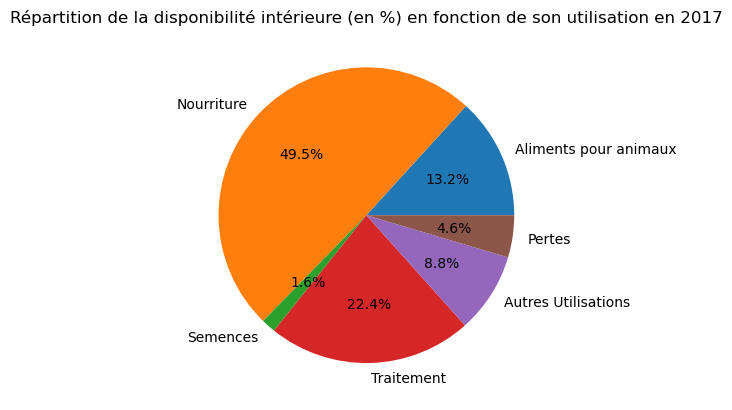

In [45]:
import matplotlib.pyplot as plt  # importe le package pyplot de la librairie matplotlib afin de pouvoir créer des graphiques

# création d'un diagramme circulaire pour illustrer le powerpoint
plt.pie(df_boucle["Proportion de la disponibilité totale (%)"], labels = df_boucle["Utilisation"], autopct = '%.1f%%') # dessine le graphique en fonction des paramètres choisis (valeurs à afficher, légende, ...)
                                                                                                                        # autopct='%.1f%%' permet d'ajouter les pourcentages sur le graphique avec 1 chiffre après la virgule.
plt.title("Répartition de la disponibilité intérieure (en %) en fonction de son utilisation en 2017")  # titre du graphique
plt.show()  # affiche le graphique

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [46]:
# Création d'une liste avec toutes les variables
liste_cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle", "Avoine", "Millet", "Sorgho", "Céréales, Autres"]

In [47]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
df_cereales = dispo_alimentaire[dispo_alimentaire["Produit"].isin(liste_cereales)].groupby("Produit").sum()  # aggrégation des données du DF en fonction du type de produit, et seulement si celui-ci est contenu dans la liste des céréales
df_cereales.drop(columns = ["Zone", "Origine"], inplace = True)   # suppression des colonnes non nécessaires du DF
df_cereales

,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
Produit,,,,,,,,,,,,,,,
Avoine,1.625100e+10,2.060000e+08,880.0,151.43,15.29,35.70,2.340700e+10,3.531000e+09,3.708000e+09,3.903000e+09,5.140000e+08,2.381600e+10,2.485000e+09,3.600000e+07,-5.770000e+08
Blé,1.296680e+11,2.242400e+10,96132.0,12339.51,548.76,2809.21,6.794980e+11,1.983800e+11,1.853770e+11,4.578240e+11,2.753000e+10,7.084430e+11,3.428300e+10,7.877000e+09,-1.594800e+10
"Céréales, Autres",1.903500e+10,1.388000e+09,1483.0,193.74,5.46,40.52,2.748500e+10,2.540000e+09,2.882000e+09,5.324000e+09,7.850000e+08,2.841200e+10,1.203000e+09,1.600000e+08,-1.267000e+09
Maïs,5.461160e+11,1.893860e+11,30903.0,3690.37,271.50,771.12,9.557990e+11,1.287870e+11,1.226910e+11,1.251840e+11,4.070100e+10,1.017029e+12,6.837000e+09,4.764800e+10,-5.513600e+10
Millet,3.306000e+09,1.960000e+08,3966.0,513.09,37.27,96.11,2.991100e+10,2.760000e+08,3.430000e+08,2.304000e+10,2.276000e+09,2.890900e+10,6.820000e+08,4.030000e+08,9.330000e+08
Orge,9.265800e+10,6.540000e+08,1814.0,263.60,7.35,52.28,1.404390e+11,4.158500e+10,3.868900e+10,6.794000e+09,4.628000e+09,1.424620e+11,8.804000e+09,2.691000e+10,8.760000e+08
Riz (Eq Blanchi),3.359400e+10,1.846400e+10,53024.0,5384.46,123.95,1027.25,4.756560e+11,4.144500e+10,3.761800e+10,3.772860e+11,2.737800e+10,4.954470e+11,1.219400e+10,6.740000e+09,-1.595800e+10
Seigle,8.099000e+09,2.000000e+07,1967.0,263.36,8.62,51.56,1.656700e+10,2.372000e+09,2.251000e+09,5.502000e+09,5.620000e+08,1.671100e+10,1.262000e+09,1.120000e+09,-2.500000e+07
Sorgho,2.480800e+10,2.049000e+09,4952.0,614.02,48.34,146.16,5.823700e+10,6.388000e+09,6.418000e+09,2.415300e+10,2.746000e+09,6.211600e+10,7.880000e+08,3.695000e+09,-3.913000e+09


In [48]:
df_cereales_ppt = dispo_alimentaire[["Produit", "Disponibilité intérieure"]][dispo_alimentaire["Produit"].isin(liste_cereales)].groupby("Produit").sum()  # DF créé pour illustrer le powerpoint

print(f"En 2017, {round((sum(df_cereales_ppt["Disponibilité intérieure"])/1000000000), 2)} milliards de kg de céréales sont disponibles pour nourrir la population mondiale.")
df_cereales_ppt

En 2017, 2407.0 milliards de kg de céréales sont disponibles pour nourrir la population mondiale.


,Disponibilité intérieure
Produit,
Avoine,2.340700e+10
Blé,6.794980e+11
"Céréales, Autres",2.748500e+10
Maïs,9.557990e+11
Millet,2.991100e+10
Orge,1.404390e+11
Riz (Eq Blanchi),4.756560e+11
Seigle,1.656700e+10
Sorgho,5.823700e+10


In [49]:
#Affichage de la proportion d'alimentation animale
prop_alim_animale = round((sum(df_cereales["Aliments pour animaux"]) / sum(df_cereales["Disponibilité intérieure"]) * 100), 2)
print(f"La proportion totale d'utilisation des céréales dans l'alimentation animale est de {prop_alim_animale} %.")


df_cereales["prop_alim_animale_individuelle"] = round(((df_cereales["Aliments pour animaux"] / df_cereales["Disponibilité intérieure"]) * 100), 2)  # calcul de la proportion d'utilisation de chaque céréale dans l'alimentation animale en %, arrondie à 2 chiffres après la virgule

print("\nLes proportions d'utilisation individuelles de chaque céréale dans l'alimentation animale (%) sont :")
df_cereales["prop_alim_animale_individuelle"]

La proportion totale d'utilisation des céréales dans l'alimentation animale est de 36.29 %.

Les proportions d'utilisation individuelles de chaque céréale dans l'alimentation animale (%) sont :


Produit
Avoine              69.43
Blé                 19.08
Céréales, Autres    69.26
Maïs                57.14
Millet              11.05
Orge                65.98
Riz (Eq Blanchi)     7.06
Seigle              48.89
Sorgho              42.60
Name: prop_alim_animale_individuelle, dtype: float64

In [50]:
#Affichage de la proportion d'alimentation humaine
prop_alim_humaine = round((sum(df_cereales["Nourriture"]) / sum(df_cereales["Disponibilité intérieure"]) * 100), 2)
print(f"La proportion totale d'utilisation des céréales dans l'alimentation humaine est de {prop_alim_humaine} %.")


df_cereales["prop_alim_humaine_individuelle"] = round(((df_cereales["Nourriture"] / df_cereales["Disponibilité intérieure"]) * 100), 2)  # calcul de la proportion d'utilisation de chaque céréale dans l'alimentation humaine en %, arrondie à 2 chiffres après la virgule

print("\nLes proportions d'utilisation individuelles de chaque céréale dans l'alimentation humaine (%) sont :")
df_cereales["prop_alim_humaine_individuelle"]

La proportion totale d'utilisation des céréales dans l'alimentation humaine est de 42.75 %.

Les proportions d'utilisation individuelles de chaque céréale dans l'alimentation humaine (%) sont :


Produit
Avoine              16.67
Blé                 67.38
Céréales, Autres    19.37
Maïs                13.10
Millet              77.03
Orge                 4.84
Riz (Eq Blanchi)    79.32
Seigle              33.21
Sorgho              41.47
Name: prop_alim_humaine_individuelle, dtype: float64

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [51]:
#Création de la colonne proportion par pays
pop_sous_nut_2017["Proportion_pop_sous_nut"] = round(((pop_sous_nut_2017["Sous_Nutrition"] / pop_sous_nut_2017["Population"]) *100), 2) # calcul de la proportion (en %) de personnes en sous-nutrition par rapport à la population totale du pays
pop_sous_nut_2017  #utilisation du DF créé précédemment, regroupant les données de population totale et des personnes en sous nutrition dans chaque pays pour l'année 2017

,Zone,Année,Population,Sous_Nutrition,Proportion_pop_sous_nut
4,Afghanistan,2017,36296113.0,10500000.0,28.93
10,Afrique du Sud,2017,57009756.0,3100000.0,5.44
16,Albanie,2017,2884169.0,100000.0,3.47
22,Algérie,2017,41389189.0,1300000.0,3.14
28,Allemagne,2017,82658409.0,0.0,0.00
...,...,...,...,...,...
1192,Venezuela (République bolivarienne du),2017,29402484.0,8000000.0,27.21
1198,Viet Nam,2017,94600648.0,6500000.0,6.87
1204,Yémen,2017,27834819.0,0.0,0.00
1210,Zambie,2017,16853599.0,0.0,0.00


In [52]:
#affichage après trie des 10 pires pays
pop_sous_nut_2017 = pop_sous_nut_2017.sort_values(by = "Proportion_pop_sous_nut", ascending = False)  # tri décroissant des valeurs de la proportion de personnes en sous-nutrition
print("En 2017, les 10 pays ayant la proportion de personnes en sous nutrition la plus forte sont :")
pop_sous_nut_2017.head(10) # affichage des 10 premières lignes, correspondant aux 10 pays ayant la proportion de personnes en sous-nutrition la plus élevée pour l'année 2017

En 2017, les 10 pays ayant la proportion de personnes en sous nutrition la plus forte sont :


,Zone,Année,Population,Sous_Nutrition,Proportion_pop_sous_nut
472,Haïti,2017,10982366.0,5300000.0,48.26
946,République populaire démocratique de Corée,2017,25429825.0,12000000.0,47.19
652,Madagascar,2017,25570512.0,10500000.0,41.06
622,Libéria,2017,4702226.0,1800000.0,38.28
604,Lesotho,2017,2091534.0,800000.0,38.25
1102,Tchad,2017,15016753.0,5700000.0,37.96
970,Rwanda,2017,11980961.0,4200000.0,35.06
730,Mozambique,2017,28649018.0,9400000.0,32.81
1120,Timor-Leste,2017,1243258.0,400000.0,32.17
4,Afghanistan,2017,36296113.0,10500000.0,28.93


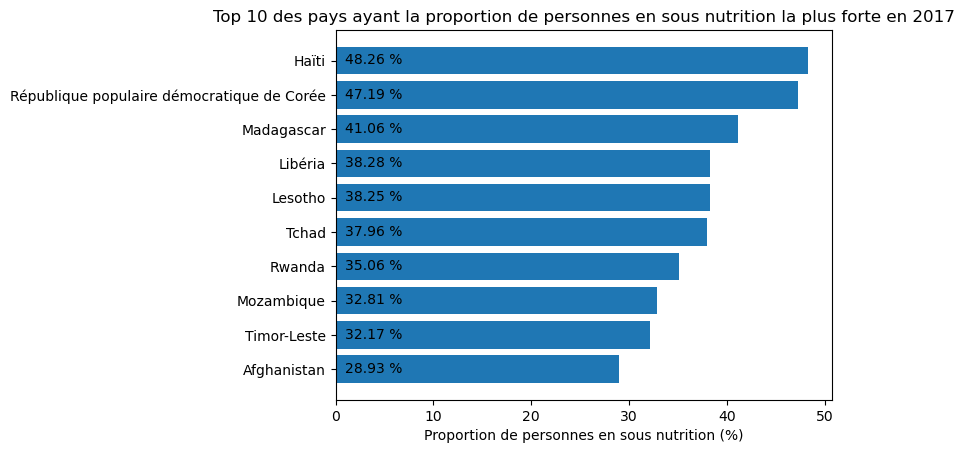

In [53]:
barres = plt.barh(pop_sous_nut_2017["Zone"].head(10), pop_sous_nut_2017["Proportion_pop_sous_nut"].head(10))  # attribution des valeurs pour les axes x (longeur de la barre) et y (légende), limitées aux 10 premières lignes du DF (head)
                                                                                                             # + stocke les caractéristiques de taille de chaque barre dans une variable "barres"
for barre in barres :
    position_y = barre.get_y()  # récupère les caractéristiques de la barre (position sur l'axe y et longueur)
    longueur = barre.get_width()
    plt.text(+1, position_y +0.5, f"{longueur} %")  # affiche la valeur demandée (légèrement décalée de la base de la barre, centrée, valeur à afficher)
plt.title("Top 10 des pays ayant la proportion de personnes en sous nutrition la plus forte en 2017")  # ajoute un titre au graphique
plt.gca().invert_yaxis() # permet d'afficher le pays ayant obtenu le plus d'aide en 1er (haut)
plt.xlabel("Proportion de personnes en sous nutrition (%)")
plt.show() # affiche le graphique

# création d'un graphique diagramme à barres horizontales pour illustrer le powerpoint

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [54]:
dates = aide_alimentaire["Année"].drop_duplicates().tolist()  # vérification des dates présentes dans le dataset pour savoir si il y a besoin de filtrer les données 
dates                                                         # pas besoin de filtrer sur les années car le dataset ne contient que les données entre 2013 et 2016

[2013, 2014, 2015, 2016]

In [55]:
#calcul du total de l'aide alimentaire par pays
total_aide_alim = aide_alimentaire.loc[:,["Zone","Valeur"]].groupby("Zone").sum()  # addition de la quantité d'aide alimentaire totale reçue par pays entre 2013 et 2016

In [56]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
total_aide_alim = total_aide_alim.sort_values(by = "Valeur", ascending = False)  # tri décroissant des valeurs de la quantité d'aide alimentaire reçue
total_aide_alim.rename(columns = {"Valeur" : "Aide_reçue (kg)"}, inplace = True)  # changement de nom de la colonne représentant l'aide alimentaire reçue pour plus de clarté
print("Les 10 pays ayant bénéficié le plus de l'aide alimentaire entre 2013 et 2016 sont :")
total_aide_alim.head(10) # affichage des 10 premières lignes, correspondant aux 10 pays ayant reçu la plus grande quantité d'aide alimentaire entre 2013 et 2016

Les 10 pays ayant bénéficié le plus de l'aide alimentaire entre 2013 et 2016 sont :


,Aide_reçue (kg)
Zone,
République arabe syrienne,1858943000
Éthiopie,1381294000
Yémen,1206484000
Soudan du Sud,695248000
Soudan,669784000
Kenya,552836000
Bangladesh,348188000
Somalie,292678000
République démocratique du Congo,288502000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [57]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
evo_aide_alim = copy.deepcopy(aide_alimentaire.loc[:,["Zone", "Année", "Valeur"]]) # création du DF en ne selectionnant que les colonnes demandées dans le dataset aide_alimentaire
                                                                                   # pas besoin de filtrer sur les années car le dataset ne contient que les données entre 2013 et 2016 (voir 1er bloc au 3.7)
evo_aide_alim.rename(columns = {"Valeur" : "Aide_reçue (kg)"}, inplace = True)  # changement de nom de la colonne représentant l'aide alimentaire reçue pour plus de clarté
evo_aide_alim = evo_aide_alim.groupby(["Zone", "Année"]).sum()  # agrégation de la valeur de l'aide alimentaire en fonction du pays et de l'année
evo_aide_alim = evo_aide_alim.reset_index()  # réinitialise les index avec que Zone et Année soient reconsidérées comme des colonnes pour la suite

In [58]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
evo_aide_alim = evo_aide_alim.sort_values(by = "Aide_reçue (kg)", ascending = False)  # tri des valeurs de l'aide alimentaire reçue par ordre décroissant, permettant d'obtenir l'apparition des pays ayant reçu l'aide la plus élevée en 1er
liste_pays = evo_aide_alim["Zone"].drop_duplicates().head(5).tolist()  # la fonction supprime les doublons pour ne sélectionner que les 5 premières valeurs uniques de Pays et les intégrer dans une liste
print(f"Les 5 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2016 sont : \n{liste_pays}.")

Les 5 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2016 sont : 
['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan'].


In [59]:
#On filtre sur le dataframe avec notre liste
evo_aide_alim = evo_aide_alim[evo_aide_alim["Zone"].isin(liste_pays)]  # filtrage des données pour n'afficher que les valeurs des 5 pays contenus dans la liste créée précédemment

In [60]:
# Affichage des pays avec l'aide alimentaire par année
evo_aide_alim = evo_aide_alim.groupby(["Zone", "Année"]).sum()   # agrégation des valeurs de l'aide alimentaire par pays et par année
print("Evolution par année des 5 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2016 :") 
evo_aide_alim

Evolution par année des 5 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2016 :


Aide_reçue (kg)
Zone                      Année                 
République arabe syrienne 2013         563566000
                          2014         651870000
                          2015         524949000
                          2016         118558000
Soudan                    2013         330230000
                          2014         321904000
                          2015          17650000
Soudan du Sud             2013         196330000
                          2014         450610000
                          2015          48308000
Yémen                     2013         264764000
                          2014         103840000
                          2015         372306000
                          2016         465574000
Éthiopie                  2013         591404000
                          2014         586624000
                          2015         203266000

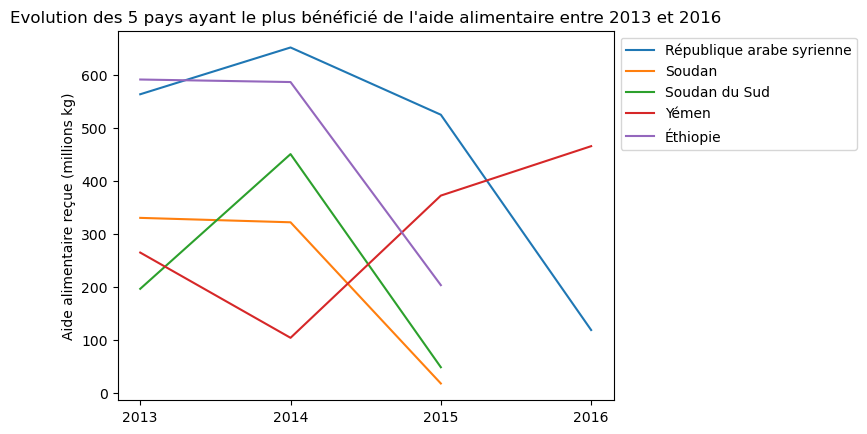

In [61]:
evo_aide_alim = evo_aide_alim.reset_index()  # réinitialise les index afin que Zone et Année soient reconsidérées comme des colonnes pour la suite
evo_aide_alim["Aide_reçue (millions kg)"] = evo_aide_alim["Aide_reçue (kg)"] / 1000000 # conversion de l'aide reçue en millions de kg pour que ce soit plus lisible sur le graphique
for zone in evo_aide_alim["Zone"].unique() :  # la boucle permet de créer une courbe pour chaque pays
    df_graph = evo_aide_alim[evo_aide_alim["Zone"] == zone] # crée un DF contenant les valeurs uniquement pour la zone concernée
    plt.plot(df_graph["Année"], df_graph["Aide_reçue (millions kg)"], label = zone)  # crée la courbe d'évolution de la zone concernée
plt.title("Evolution des 5 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2016")  # ajoute un titre au graphique
plt.ylabel("Aide alimentaire reçue (millions kg)")  # ajoute un titre à l'axe y pour rappeler à quoi correspondent les valeurs affichées
plt.xticks(sorted(evo_aide_alim["Année"].unique()))  # permet d'afficher les années par ordre chronologique (sorted) et d'éviter les répétitions (unique)
plt.legend(bbox_to_anchor = (1, 1))  # regroupe toutes les courbes sur le même graphique, "bbox_to_anchor" permet de déplacer la légende en dehors du graphique pour plus de lisibilité
plt.show()  # affiche le graphique combiné

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [62]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_kcal_pays = dispo_alimentaire.loc[:,["Zone", "Disponibilité alimentaire (Kcal/personne/jour)"]].groupby("Zone").sum()  # selection des colonnes pertinentes et agrégation des valeurs de disponibilité alimentaire en fonction des pays
dispo_kcal_pays

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Afghanistan,2087.0
Afrique du Sud,3020.0
Albanie,3188.0
Algérie,3293.0
Allemagne,3503.0
...,...
Émirats arabes unis,3275.0
Équateur,2346.0
États-Unis d'Amérique,3682.0


In [63]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
dispo_kcal_pays = dispo_kcal_pays.sort_values(by = "Disponibilité alimentaire (Kcal/personne/jour)", ascending = True) # tri des données de disponibilité alimentaire par ordre croissant
print("En 2017, les 10 pays ayant le moins de disponibilité alimentaire par personne sont :")
dispo_kcal_pays.head(10)  # affichage des 10 premières lignes, qui correspondent grâce au tri précédent, aux 10 pays ayant le moins de disponibilité alimentaire

En 2017, les 10 pays ayant le moins de disponibilité alimentaire par personne sont :


,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0


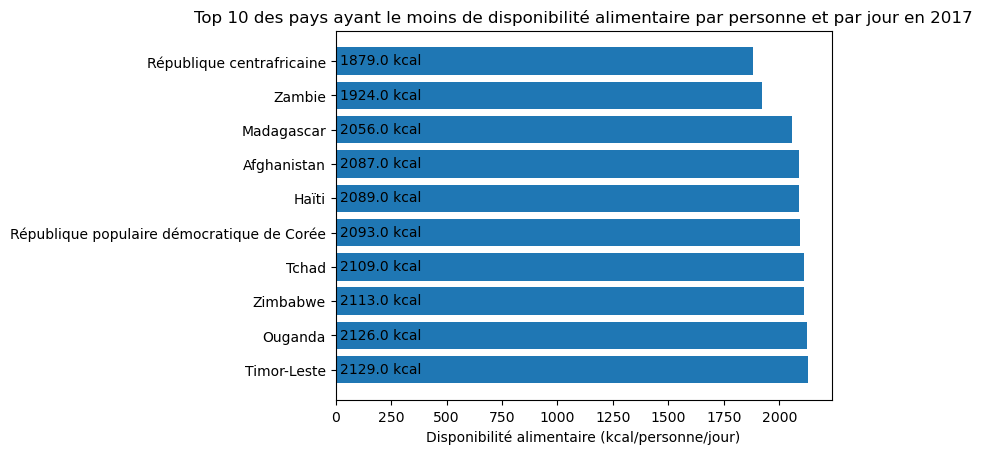

In [64]:
dispo_kcal_pays = dispo_kcal_pays.reset_index()  # réinitialise les index afin que Zone soit reconsidérée comme une colonne pour la suite
barres = plt.barh(dispo_kcal_pays["Zone"].head(10), dispo_kcal_pays["Disponibilité alimentaire (Kcal/personne/jour)"].head(10))  # attribution des valeurs pour les axes x (longeur de la barre) et y (légende), limitées aux 10 premières lignes du DF (head)
                                                                                                                                 # + stocke les caractéristiques de taille de chaque barre dans une variable "barres"
for barre in barres :
    position_y = barre.get_y()  # récupère les caractéristiques de la barre (position sur l'axe y et longueur)
    longueur = barre.get_width()
    plt.text(+20, position_y +0.5 , f"{longueur} kcal")  # affiche la valeur demandée (décalée de la base de la barre, centrée, valeur à afficher)
plt.title("Top 10 des pays ayant le moins de disponibilité alimentaire par personne et par jour en 2017")  # ajoute un titre au graphique
plt.xlabel("Disponibilité alimentaire (kcal/personne/jour)")
plt.gca().invert_yaxis() # permet d'afficher le pays ayant le moins de disponibilité en 1er (haut)
plt.show() # affiche le graphique

# création d'un graphique diagramme à barres horizontales pour illustrer le powerpoint

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [65]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
print("En 2017, les 10 pays ayant le plus de disponibilité alimentaire par personne sont :")
dispo_kcal_pays.tail(10) # affichage des 10 dernières lignes du DF précédent, qui correspondent grâce au tri effectué, aux 10 pays ayant le plus de disponibilité alimentaire

En 2017, les 10 pays ayant le plus de disponibilité alimentaire par personne sont :


,Zone,Disponibilité alimentaire (Kcal/personne/jour)
164,Allemagne,3503.0
165,Égypte,3518.0
166,Luxembourg,3540.0
167,Italie,3578.0
168,Irlande,3602.0
169,Israël,3610.0
170,États-Unis d'Amérique,3682.0
171,Turquie,3708.0
172,Belgique,3737.0
173,Autriche,3770.0


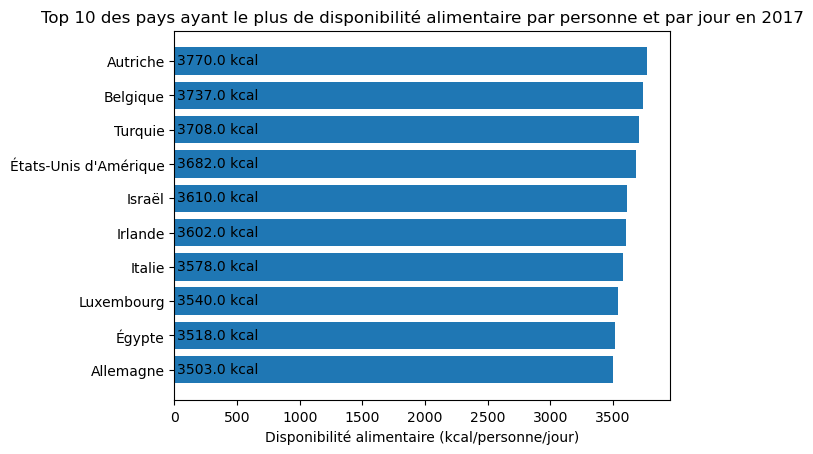

In [66]:
barres = plt.barh(dispo_kcal_pays["Zone"].tail(10), dispo_kcal_pays["Disponibilité alimentaire (Kcal/personne/jour)"].tail(10))  # attribution des valeurs pour les axes x (longeur de la barre) et y (légende), limitées aux 10 dernières lignes du DF (tail)
                                                                                                                                 # + stocke les caractéristiques de taille de chaque barre dans une variable "barres"
for barre in barres :
    position_y = barre.get_y()  # récupère les caractéristiques de la barre (position sur l'axe y et longueur)
    longueur = barre.get_width()
    plt.text(+20, position_y +0.3 , f"{longueur} kcal")  # affiche la valeur demandée (décalée de la base de la barre, centrée, valeur à afficher)
plt.title("Top 10 des pays ayant le plus de disponibilité alimentaire par personne et par jour en 2017")  # ajoute un titre au graphique
plt.xlabel("Disponibilité alimentaire (kcal/personne/jour)")
plt.show() # affiche le graphique

# création d'un graphique diagramme à barres horizontales pour illustrer le powerpoint

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [67]:
#création d'un dataframe avec uniquement la Thaïlande 
df_Thailande = pd.merge(pop_sous_nut_2017, dispo_alimentaire, on = "Zone", how = "inner")  # fusion des DF "population", "sous_nutrition" et "dispo_alimentaire"
                                                                             # utilisation du DF pop_sous_nut_2017 qui merge déjà "population" et "sous-nutrition" sur "Zone" et "Année" pour l'année 2017 (année unique présente également dans le dataset dispo_alimentaire)
                                                                             # il n'y a pas de données d'aide_alimentaire pour la Thaïlande donc il n'est pas nécessaire de fusionnner ce dataset
df_Thailande = df_Thailande[df_Thailande["Zone"] == "Thaïlande"] # filtre les pays pour ne conserver que les données concernant la Thaïlande

In [68]:
#Calcul de la sous nutrition en Thaïlande
valeur_sous_nut = df_Thailande["Sous_Nutrition"].unique()[0]  # extrait la valeur unique de la colonne "Sous_Nutrition" ([0] = index de la 1ère ligne) pour le nombre de personnes en sous nutrition en Thailande en 2017
valeur_population = df_Thailande["Population"].unique()[0]  # extrait la valeur unique de la colonne "Population" ([0] = index de la 1ère ligne) pour le nombre de personnes constituant la population totale en Thailande en 2017
prop_sous_nut_Thai = valeur_sous_nut / valeur_population * 100 # calcule la proportion de personnes en sous nutrition par rapport à la population totale de la Thaïlande en 2017
print(f"En 2017, {round(valeur_sous_nut/1000000,2)} millions de personnes étaient en état de sous nutrition en Thaïlande, ce qui représentait {round(prop_sous_nut_Thai,2)} % de sa population totale.")

En 2017, 6.2 millions de personnes étaient en état de sous nutrition en Thaïlande, ce qui représentait 8.96 % de sa population totale.


In [69]:
# On calcule la proportion exportée en fonction de la production
df_Thailande_manioc = df_Thailande[df_Thailande["Produit"] == "Manioc"]  # création d'un DF ne contenant que les données de la Thailande correspondant au Manioc en 2017
qte_exportee = df_Thailande_manioc["Exportations - Quantité"].unique()[0]  # extrait la valeur unique de la colonne "Exportations - Quantité" ([0] = index de la 1ère ligne) pour la quantité de manioc exporté
qte_produite = df_Thailande_manioc["Production"].unique()[0]  # extrait la valeur unique de la colonne "Produit" ([0] = index de la 1ère ligne) pour la quantité de manioc produit
prop_export = qte_exportee / qte_produite * 100  # calcul de la proportion de manioc exporté par rapport à la quantité produite par la Thailande en 2017
print(f" En 2017, {round(qte_exportee/1000000000, 2)} milliards de kg de Manioc ont été exportés, contre {round(qte_produite/1000000000, 2)} milliards de kg produits, ce qui représente {round(prop_export, 2)} % de sa production.")

 En 2017, 25.21 milliards de kg de Manioc ont été exportés, contre 30.23 milliards de kg produits, ce qui représente 83.41 % de sa production.


In [70]:
liste_utilisation = ["Exportations - Quantité", "Nourriture", "Aliments pour animaux", "Semences", "Traitement", "Autres Utilisations", "Pertes"]  # liste des colonnes correspondant à un type d'utilisation du manioc
resultats_boucle = [] # création d'une liste permettant de stocker les résulats obtenus par la boucle
for utilisation in liste_utilisation :
    qte_dispo = df_Thailande_manioc[utilisation].unique()[0]  # recupération de la valeur de la disponibilité totale pour chaque type d'utilisation ([0] = index de la ligne)
    qte_prod = df_Thailande_manioc["Production"].unique()[0]  # recupération de la valeur de la quantité de manioc produite par la Thailande
    prop_prod = round((qte_dispo / qte_prod *100), 2)  # calcul de la proportion de disponibilité utilisée pour chaque type d'utilisation par rapport à la quantité produite par la Thailande
    resultats_boucle.append({"Utilisation" : utilisation, "Disponibilité (kg)" : qte_dispo, "Proportion_production (%)" : prop_prod}) # ajoute les résultats obtenus dans la liste "résultats" au fur et à mesure de la boucle
df_boucle_manioc = pd.DataFrame(resultats_boucle)  # création d'un DF pour afficher les résultats de façon plus lisible et pour pouvoir faire un graphique par la suite
df_boucle_manioc

# Proportions des autres utilisations du manioc par rapport à la production en Thailande

,Utilisation,Disponibilité (kg),Proportion_production (%)
0,Exportations - Quantité,2.521400e+10,83.41
1,Nourriture,8.710000e+08,2.88
2,Aliments pour animaux,1.800000e+09,5.95
3,Semences,0.000000e+00,0.00
4,Traitement,0.000000e+00,0.00
5,Autres Utilisations,2.081000e+09,6.88
6,Pertes,1.511000e+09,5.00


In [71]:
dispo_manioc_kcal = df_Thailande_manioc["Disponibilité alimentaire (Kcal/personne/jour)"].unique()[0]  # récupération de la valeur de la disponibilité alimentaire en kcal pour le manioc
dispo_manioc_kg = (df_Thailande_manioc["Disponibilité alimentaire en quantité (kg/personne/an)"].unique()[0]) / 365  # récupération de la valeur de la disponibilité alimentaire en kg pour le manioc et division par 365 pour convertir en kg/pers/jour

print(f"En 2017, {dispo_manioc_kcal} kcal, ou {round(dispo_manioc_kg, 3)} kg, de manioc étaient disponibles chaque jour par personne pour nourrir la population de la Thailande.")

En 2017, 40.0 kcal, ou 0.036 kg, de manioc étaient disponibles chaque jour par personne pour nourrir la population de la Thailande.


In [72]:
population = df_Thailande_manioc["Population"].unique()[0]  # récupération de la valeur de la population pour la Thailande
prod_totale = df_Thailande_manioc["Production"].unique()[0] # récupération de la quantité de manioc produite par la Thailande
importation = df_Thailande_manioc["Importations - Quantité"].unique()[0] # récupération de la quantité de manioc exportée par la Thailande
var_stock = df_Thailande_manioc["Variation de stock"].unique()[0] # récupération de la quantité de variation de stock pour le manioc
dispo_int_corrigee =  prod_totale + importation + var_stock  # calcul de la disponibilité intérieure du manioc si la Thailande utilisait l'intégralité de sa production pour nourrir sa population
dispo_alim_corrigee = (dispo_int_corrigee / population) / 365 # conversion de la nouvelle disponibilité intérieure pour obtenir la disponibilité alimentaire en kg/pers/jour
dispo_kcal_corrigee = (dispo_alim_corrigee * dispo_manioc_kcal / dispo_manioc_kg) * population  # calcul de l'équivalent de la nouvelle disponibilité alimentaire total en kcal/jour
nb_pers_nourries_corrige = dispo_kcal_corrigee / 2250  # calcul du nombre de personnes qui pourraient être nourries avec la nouvelle disponibilité intérieure (si l'intégralité de la production était utilisée)

print(f"Si l'intégralité de la production de manioc avait été utilisée, en plus de la quantité importée, \nil aurait été possible de nourrir {round(nb_pers_nourries_corrige/1000000, 2)} millions de personnes avec la production de manioc en 2017.")

Si l'intégralité de la production de manioc avait été utilisée, en plus de la quantité importée, 
il aurait été possible de nourrir 43.05 millions de personnes avec la production de manioc en 2017.


In [73]:
dispo_totale_Thai = sum(df_Thailande["Disponibilité alimentaire (Kcal/personne/jour)"]) * population  # calcul de la disponibilité alimentaire totale de la Thailande (out produits confondus)
dispo_manioc_2017 = dispo_manioc_kcal * population # disponibilité alimentaire du manioc sans la quantité exportée
nouvelle_dispo_manioc = dispo_kcal_corrigee  # disponibilité alimentaire du manioc incluant la production exportée
nouvelle_dispo_alim =  dispo_totale_Thai - dispo_manioc_2017 + nouvelle_dispo_manioc  # correction de la disponibilité alimentaire totale en incluant la quantité de manioc exportée
nvx_nb_pers_nourries = nouvelle_dispo_alim / 2250 # calcul du nombre total de personnes pouvant être nourries avec la disponibilité alimentaire si la Thailande utilisait l'intégralité de sa production de manioc

print(f"Si l'intégralité de la production de manioc avait été utilisée, {round(nvx_nb_pers_nourries/1000000,2)} millions de personnes pourraient être nourries au total par la Thailande.")


Si l'intégralité de la production de manioc avait été utilisée, 127.48 millions de personnes pourraient être nourries au total par la Thailande.


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [74]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être le plus en difficulté au niveau alimentaire"

In [75]:
# Analyse approfondie des pays le plus en difficulté au niveau alimentaire :
    # pays ayant le taux de sous nutrition le plus élevé en 2017 : 
pays_sous_nut = pop_sous_nut_2017["Zone"].head(3).tolist()
print(f"En 2017, les 3 pays ayant le taux de sous nutrition le plus élevé sont : \n{pays_sous_nut}")

    # pays ayant le moins de disponibilité alimentaire en 2017 :
pays_dispo = dispo_kcal_pays["Zone"].head(3).tolist()
print(f"\nEn 2017, les 3 pays ayant le moins de disponibilité alimentaire pour nourrir leur population étaient : \n{pays_dispo}")

    # pays ayant bénéficié le plus de l'aide alimentaire entre 2013 et 2016 :
pays_aide = evo_aide_alim["Zone"].drop_duplicates().head(3).tolist()
print(f"\nLes 3 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2017 sont : \n{pays_aide}.")

En 2017, les 3 pays ayant le taux de sous nutrition le plus élevé sont : 
['Haïti', 'République populaire démocratique de Corée', 'Madagascar']

En 2017, les 3 pays ayant le moins de disponibilité alimentaire pour nourrir leur population étaient : 
['République centrafricaine', 'Zambie', 'Madagascar']

Les 3 pays ayant le plus bénéficié de l'aide alimentaire entre 2013 et 2017 sont : 
['République arabe syrienne', 'Soudan', 'Soudan du Sud'].


In [76]:
# Analyse approfondie des pays ayant le taux de sous nutrition le plus élevé en 2017 : exemple d'Haïti
    # Proportion de la sous nutrition dans le pays en 2016 et 2017 + aide alimentaire reçue
sous_nut_Haiti = copy.deepcopy(pop_sous_nut[pop_sous_nut["Zone"] == "Haïti"])
sous_nut_Haiti = sous_nut_Haiti[sous_nut_Haiti["Année"] == 2017]
sous_nut_Haiti["Proportion sous nutrition (%)"] = round((sous_nut_Haiti["Sous_Nutrition"] / sous_nut_Haiti["Population"] * 100), 2)
sous_nut_Haiti.rename(columns = {"Sous_Nutrition" : "Nb personnes en sous nutrition"}, inplace = True)
sous_nut_Haiti["Aide_reçue_2016 (kg)"] = sum(aide_alimentaire["Valeur"][(aide_alimentaire["Zone"] == "Haïti") & (aide_alimentaire["Année"] == 2016)])


    # Disponibilité intérieure du pays en 2017 + provenance (import vs production)
dispo_Haiti = dispo_alimentaire[(dispo_alimentaire["Zone"] == "Haïti")]
liste_provenance = ["Importations - Quantité", "Production"]
resultat_boucle_Haiti = []
for provenance in liste_provenance :
    qte_dispo = sum(dispo_Haiti[provenance])
    prop_dispo = round((qte_dispo / sum(dispo_Haiti["Disponibilité intérieure"]) * 100), 2)
    resultat_boucle_Haiti.append({"Provenance" : provenance, "Quantité disponible (kg)" : qte_dispo, "Proportion rapport Dispo_int (%)" : prop_dispo})
dispo_Haiti_2017 = pd.DataFrame(resultat_boucle_Haiti)
dispo_Haiti_2017["Disponibilité intérieure (kg)"] = sum(dispo_Haiti["Disponibilité intérieure"])


    # Utilisation de la disponibilité intérieure totale et de la production
liste_utilisation_v2 = ["Exportations - Quantité", "Nourriture", "Aliments pour animaux", "Semences", "Traitement", "Autres Utilisations", "Pertes"] 
resultats_boucle_utilisation_Haiti = []
for utilisation in liste_utilisation_v2 :
    dispo_utilisation = sum(dispo_Haiti[utilisation])
    dispo_int = sum(dispo_Haiti["Disponibilité intérieure"])
    prop_dispo_int = round((dispo_utilisation / dispo_int * 100), 2)
    prod = sum(dispo_Haiti["Production"])
    prop_prod = round((dispo_utilisation / prod * 100), 2)
    resultats_boucle_utilisation_Haiti.append({"Utilisation" : utilisation, "Disponibilité totale (kg)" : dispo_utilisation, "Proportion rapport Dispo_int (%)" : prop_dispo_int, "Production (kg)" : prod, "Proportion rapport Prod (%)" : prop_prod}) 
df_utilisation_Haiti = pd.DataFrame(resultats_boucle_utilisation_Haiti)


    # Combien de personnes pourraient être nourries avec la disponibilité intérieure totale (kcal/personne/jour)
pop_Haiti = sous_nut_Haiti["Population"].unique()[0]
dispo_alim_totale_Haiti = sum(dispo_Haiti["Disponibilité alimentaire (Kcal/personne/jour)"]) * pop_Haiti
sous_nut_Haiti["Possibilité nb pers nourries (dispo alim totale)"] = dispo_alim_totale_Haiti / 2250 


    # Prise en compte de la proportion de la disponibilité totale utilisée pour la nourriture
dispo_alim_humaine_Haiti = dispo_alim_totale_Haiti * 0.66
sous_nut_Haiti["Possibilité nb pers nourries (dispo alim Nourriture)"] = dispo_alim_humaine_Haiti / 2250


    # Combien de personnes pourraient être nourries grâce à la production du pays
dispo_alim_prod_Haiti = dispo_alim_totale_Haiti * 0.82
sous_nut_Haiti["Possibilité nb pers nourries (Prod)"] = dispo_alim_prod_Haiti / 2250 


    # Combien de personnes pourraient être nourries grâce aux pertes
dispo_alim_prod_Haiti = dispo_alim_totale_Haiti * 0.11
sous_nut_Haiti["Possibilité nb pers nourries (Pertes)"] = dispo_alim_prod_Haiti / 2250 



In [77]:
sous_nut_Haiti

,Zone,Année,Population,Nb personnes en sous nutrition,Proportion sous nutrition (%),Aide_reçue_2016 (kg),Possibilité nb pers nourries (dispo alim totale),Possibilité nb pers nourries (dispo alim Nourriture),Possibilité nb pers nourries (Prod),Possibilité nb pers nourries (Pertes)
472,Haïti,2017,10982366.0,5300000.0,48.26,12462000,1.019652e+07,6.729701e+06,8.361144e+06,1.121617e+06


In [78]:
dispo_Haiti_2017

,Provenance,Quantité disponible (kg),Proportion rapport Dispo_int (%),Disponibilité intérieure (kg)
0,Importations - Quantité,1.204000e+09,19.50,6.175000e+09
1,Production,5.072000e+09,82.14,6.175000e+09


In [79]:
df_utilisation_Haiti

,Utilisation,Disponibilité totale (kg),Proportion rapport Dispo_int (%),Production (kg),Proportion rapport Prod (%)
0,Exportations - Quantité,1.500000e+07,0.24,5.072000e+09,0.30
1,Nourriture,4.101000e+09,66.41,5.072000e+09,80.86
2,Aliments pour animaux,4.810000e+08,7.79,5.072000e+09,9.48
3,Semences,3.600000e+07,0.58,5.072000e+09,0.71
4,Traitement,7.620000e+08,12.34,5.072000e+09,15.02
5,Autres Utilisations,1.150000e+08,1.86,5.072000e+09,2.27
6,Pertes,6.790000e+08,11.00,5.072000e+09,13.39
